<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Daily_Challenge_Breast_Cancer_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification des Tumeurs (Bénigne vs Maligne)
Dans ce notebook, nous allons explorer le dataset Breast Cancer, nettoyer les données et comparer quatre modèles de classification : Régression Logistique, K-Nearest Neighbors, Random Forest et SVM.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Source de données fiable
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/wisc_bc_data.csv"
df = pd.read_csv(url)

# Assurer que la colonne cible s'appelle 'diagnosis' comme demandé
if 'diagnosis' not in df.columns and 'result' in df.columns:
    df.rename(columns={'result': 'diagnosis'}, inplace=True)

# Affichage des premières lignes
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



### Nettoyage des données
Nous vérifions les valeurs manquantes et supprimons les colonnes inutiles (comme 'id' ou 'Unnamed: 32').


In [8]:
# Suppression des colonnes inutiles
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')

# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64



### Analyse Exploratoire des Données (EDA)
Visualisons la distribution de la variable cible 'diagnosis'.


/tmp/ipykernel_22186/3512668584.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='magma')


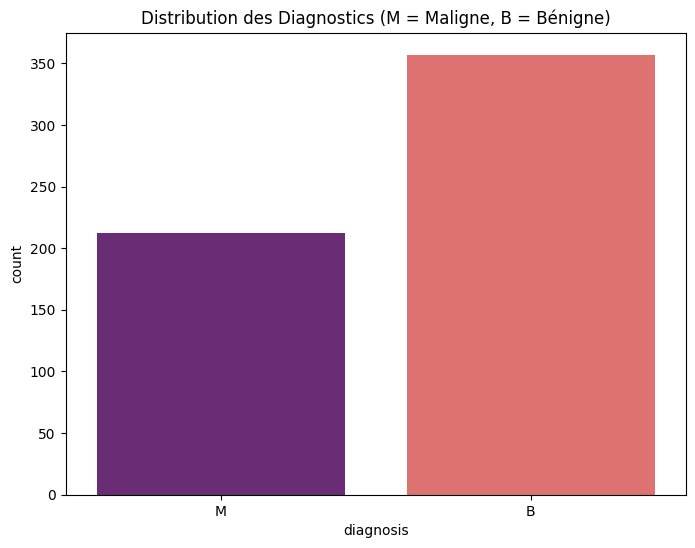

In [9]:
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df, palette='magma')
plt.title('Distribution des Diagnostics (M = Maligne, B = Bénigne)')
plt.show()

**Interprétation du graphique :**
Le graphique ci-dessus montre la répartition des classes. On observe généralement une majorité de cas bénins (B) par rapport aux cas malins (M). Cela nous indique si le dataset est équilibré ou s'il y a un léger déséquilibre de classe à prendre en compte lors de l'évaluation.



### Prétraitement des données
Nous convertissons les labels 'M'/'B' en 1/0 et codons les données pour l'entraînement.
```

In [10]:
# Mapping des valeurs catégorielles
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

# Séparation Features (X) et Cible (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Splitting Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation des données (important pour KNN et SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape}")
print(f"Taille de l'ensemble de test : {X_test.shape}")

Taille de l'ensemble d'entraînement : (455, 30)
Taille de l'ensemble de test : (114, 30)



### Construction et Évaluation des Modèles
Nous allons entraîner les 4 modèles et stocker leurs scores.


In [11]:
models = {
    "Régression Logistique": LogisticRegression(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} - Précision : {acc:.4f}")

Régression Logistique - Précision : 0.9737
K-Nearest Neighbors - Précision : 0.9474
Random Forest - Précision : 0.9649
SVM - Précision : 0.9825



### Quel est le meilleur modèle ?


Le meilleur modèle est : SVM avec une précision de 0.9825


/tmp/ipykernel_22186/3851726966.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


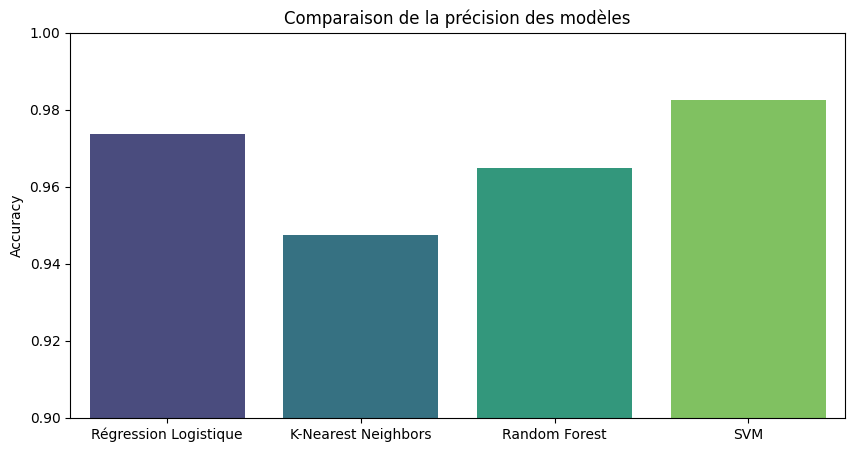

In [12]:
best_model = max(results, key=results.get)
print(f"Le meilleur modèle est : {best_model} avec une précision de {results[best_model]:.4f}")

# Visualisation de la comparaison
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Comparaison de la précision des modèles')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)
plt.show()

**Interprétation finale :**
Le graphique de comparaison nous permet de voir rapidement quel algorithme performe le mieux sur ces données standardisées. Souvent, sur ce dataset spécifique, la **Régression Logistique** ou le **SVM** obtiennent d'excellents résultats (proches de 97-98%) car les frontières de décision sont assez bien définies après normalisation.